In [ ]:
from nrem_sc.constants import PROCESSED_DATA_PATH, INTERIM_DATA_PATH
from nrem_sc.utils import circ_bin_average

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pynapple as nap
import seaborn as sns

from replay_trajectory_classification import SortedSpikesDecoder, SortedSpikesClassifier
from replay_trajectory_classification import make_track_graph, plot_track_graph
from replay_trajectory_classification import SortedSpikesClassifier, Environment, RandomWalk, Uniform, Identity, estimate_movement_var, DiagonalDiscrete
from pycircstat2.descriptive import circ_dist

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_context("notebook", font_scale=1.5, rc=custom_params)
unit_id = '116b'

def crmse(x, target):
    """Circular Root Mean Square Error"""
    return np.sqrt(np.mean(circ_dist(x, target)**2))

def mace(x, target):
    """Mean Absolute Circular Error"""
    return np.mean(np.abs(circ_dist(x, target)))

def get_environment(num_nodes=360, radius=180/np.pi, place_bin_size=1.0):
    angle = np.linspace(2*np.pi, 0, num=num_nodes, endpoint=False)
    node_positions = np.stack((radius * np.cos(angle), radius * np.sin(angle)), axis=1)

    node_ids = np.arange(node_positions.shape[0])
    edges = np.stack((node_ids, np.roll(node_ids, shift=1)), axis=1)

    track_graph = make_track_graph(node_positions, edges)

    edge_spacing = 0
    n_nodes = len(track_graph.nodes)
    edge_order = np.stack((np.roll(np.arange(n_nodes-1, -1, -1), 1),
                        np.arange(n_nodes-1, -1, -1)), axis=1)

    environment = Environment(
        place_bin_size=place_bin_size,
        track_graph=track_graph,
        edge_order=edge_order,
        edge_spacing=edge_spacing
        )
    return environment

def compare_timeseries(true, decoded, times=None, error=True):
    assert len(true) == len(decoded)
    if times is None:
        times = np.arange(len(true))
    
    if error:
        print(f'MACE: {mace(decoded, true):.3f}')
        print(f'CRME: {crmse(decoded, true):.3f}')

    plt.figure(figsize=(20, 6))
    plt.plot(times, decoded, label='Decoded angle')
    plt.plot(times, true, label='Actual angle')
    plt.xlabel('Time (s)')
    plt.ylabel('Degrees')
    plt.legend()
    plt.show()

def compare_heatmap(true, feature, times=None):

    plt.figure(figsize=(22, 6))
    plt.plot(times, true, 'w', linewidth=1, label='Actual angle', zorder=1)
    
    plt.imshow(feature.T,
            aspect='auto',
            interpolation='bilinear',
            extent=[times[0], times[-1], true.min(), true.max()],
            origin='lower',
            cmap='viridis',
            )

    plt.xlabel('Time (s)')
    plt.ylabel('Degrees')
    plt.colorbar(label='Probability')
    plt.show()
    
# Load data
sleep_states    = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sleep.npz")
hd_spikes       = nap.load_file(PROCESSED_DATA_PATH / unit_id / "hd_spikes_filtered.npz")
hd_angle        = nap.load_file(PROCESSED_DATA_PATH / unit_id / "angle_openfield.npz")
sessions        = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sessions_labeled.npz")

In [15]:
bin_size = 1

ep = nap.IntervalSet([16800], [18000])
spikes = hd_spikes.count(bin_size=bin_size, ep=ep, time_units='ms').astype(np.bool)
angle = circ_bin_average(tsd=hd_angle, bin_size=bin_size, ep=ep, time_units='ms').to_numpy()

t, spikes = spikes.times(), spikes.to_numpy()

is_training = np.ones_like(angle, dtype=bool)
is_training[int(len(angle)*0.8):] = False
is_training

array([ True,  True,  True, ..., False, False, False], shape=(1200000,))

### decoding

In [21]:
p_state = 0.90
movement_var = 2.0 * bin_size
place_bin_size = 1.0

environment = get_environment(place_bin_size=place_bin_size)
continuous_transition_types = [[RandomWalk(movement_var=movement_var),  Uniform(), Identity()],
                                [Uniform(),                    Uniform(), Uniform()],
                                [RandomWalk(movement_var=movement_var), Uniform(), Identity()]]
classifier = SortedSpikesClassifier(
    environments=environment,
    continuous_transition_types=continuous_transition_types,
    discrete_transition_type=DiagonalDiscrete(p_state),
)

classifier.fit(angle, spikes, is_training=is_training)
print(f"Average time spent in state per bin: {2/(1-p_state):.2f} ms")

c:\Users\iii9781\nrem_sc\.venv\Lib\site-packages\replay_trajectory_classification\likelihoods\spiking_likelihood_kde.py:119: RuntimeWarning: divide by zero encountered in log
  return np.exp(np.log(mean_rate) + np.log(marginal_density) - np.log(occupancy))


Average time spent in state per bin: 20.00 ms


In [22]:
decoded = classifier.predict(spikes[~is_training], state_names=['continuous', 'fragmented', 'stationary'])

  0%|          | 0/81 [00:00<?, ?it/s]

### post-processing

In [23]:
from scipy.ndimage import gaussian_filter
feature = decoded.acausal_posterior.sum(dim="state")
feature = gaussian_filter(feature, sigma=1)

pos_max = decoded.acausal_posterior.sum(dim="state").idxmax(dim="position").to_numpy()

p_state: 0.9, movement_var: 2.0, place_bin_size: 1.0, bin_size: 1
MACE: 1.569
CRME: 1.814


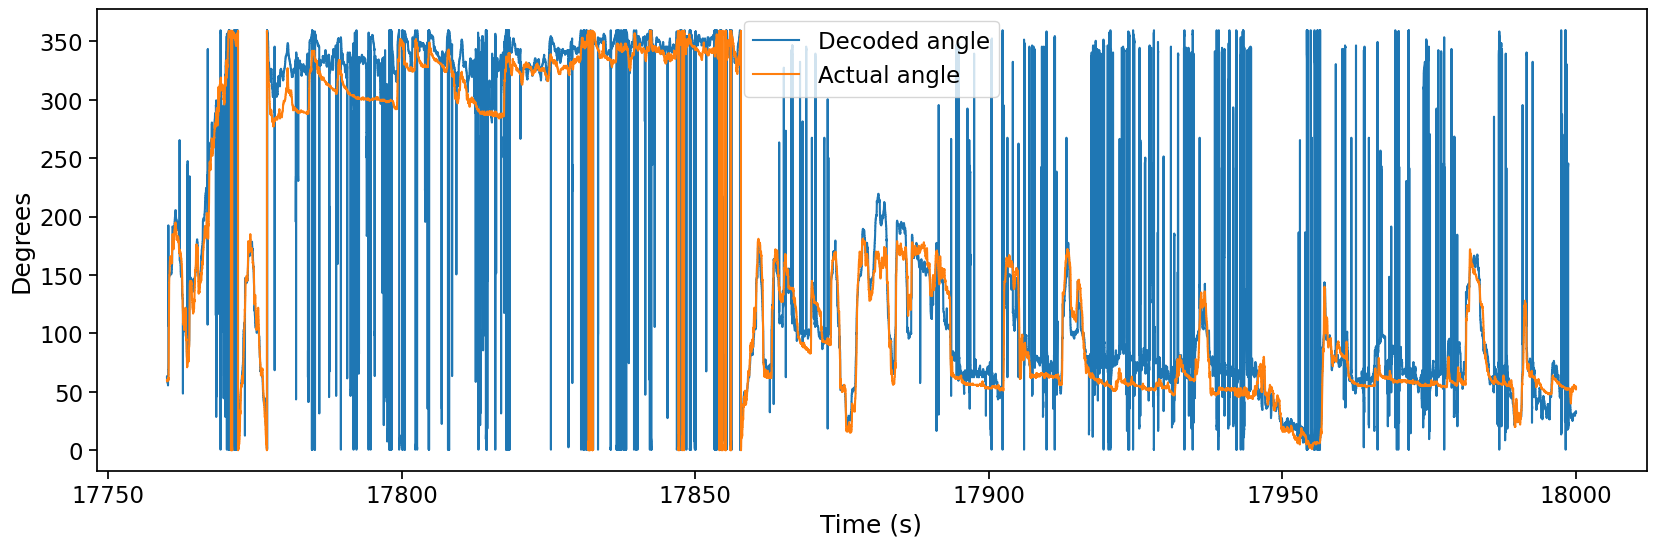

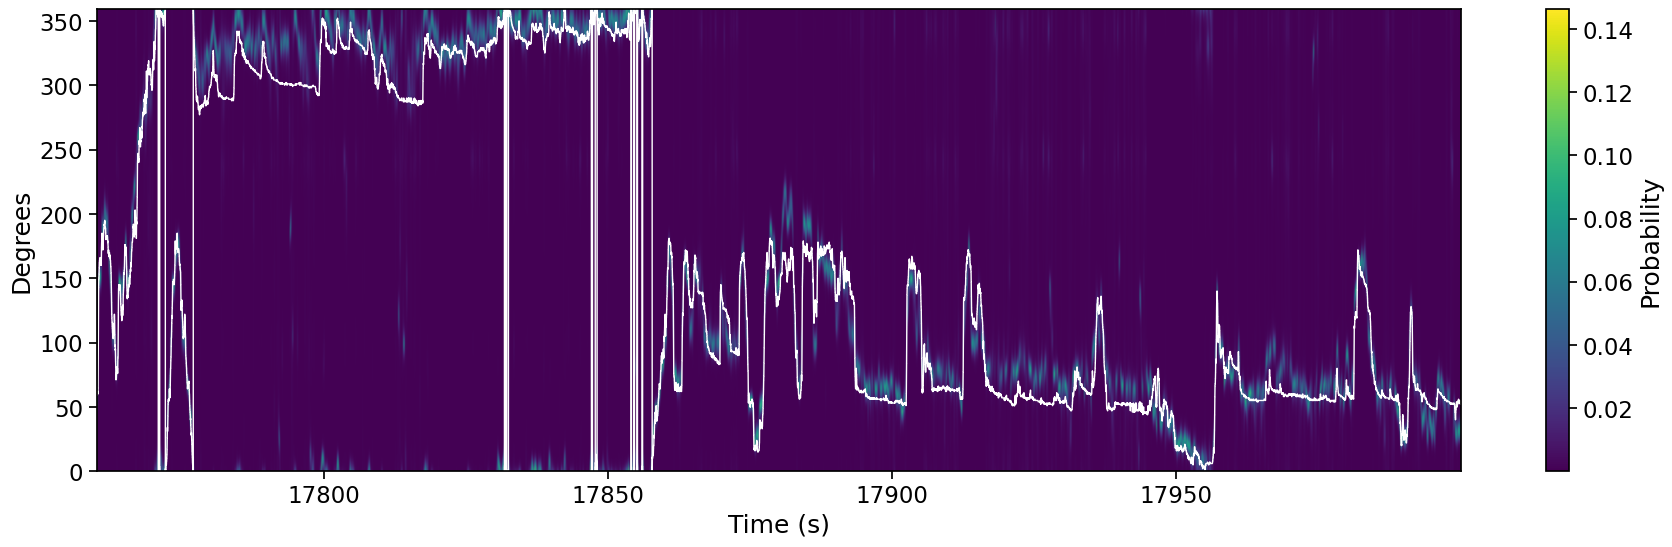

In [24]:
d = angle[~is_training]
times = t[~is_training]

print(f"p_state: {p_state}, movement_var: {movement_var}, place_bin_size: {place_bin_size}, bin_size: {bin_size}")
compare_timeseries(d, pos_max, times=times)
compare_heatmap(d, feature, times=times)

p_state: 0.85, movement_var: 20.0, place_bin_size: 1.0
MACE: 1.584
CRME: 1.825


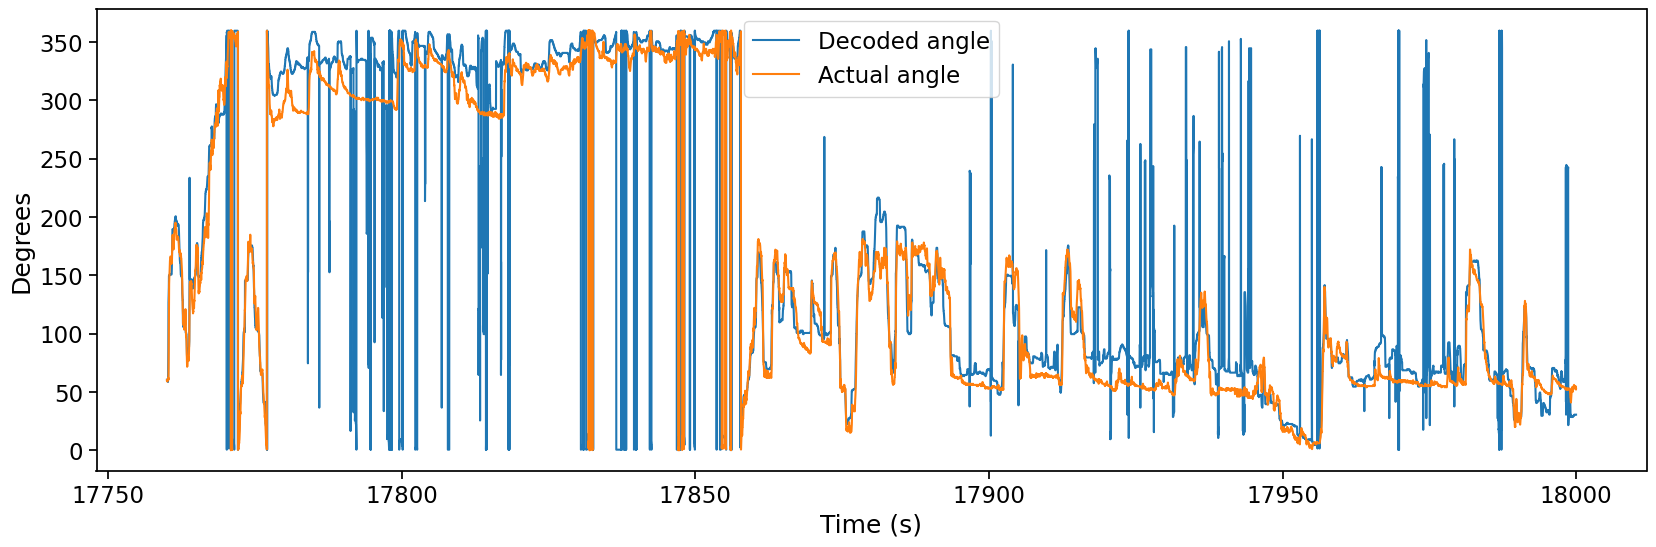

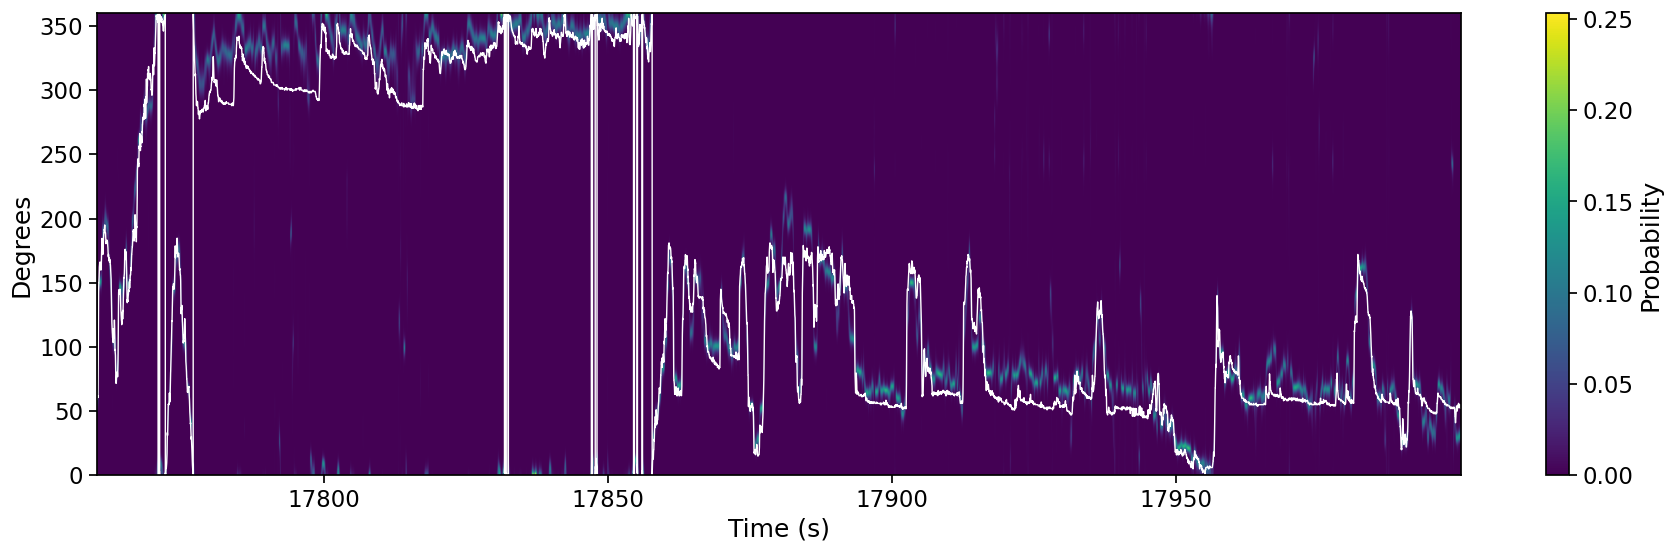

In [6]:
d = angle[~is_training]
times = t[~is_training]

print(f"p_state: {p_state}, movement_var: {movement_var}, place_bin_size: {place_bin_size}")
compare_timeseries(d, pos_max, times=times)
compare_heatmap(d, feature, times=times)

p_state: 0.99, movement_var: 2.0, place_bin_size: 1.0
MACE: 1.589
CRME: 1.827


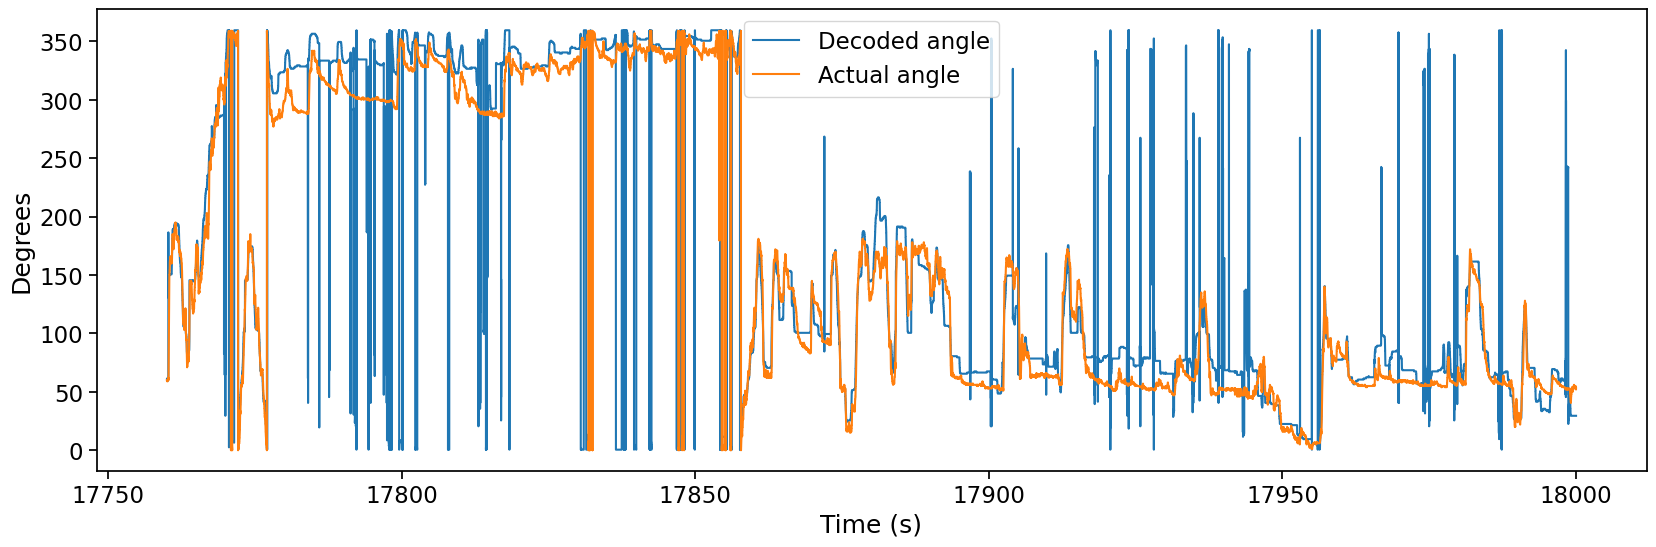

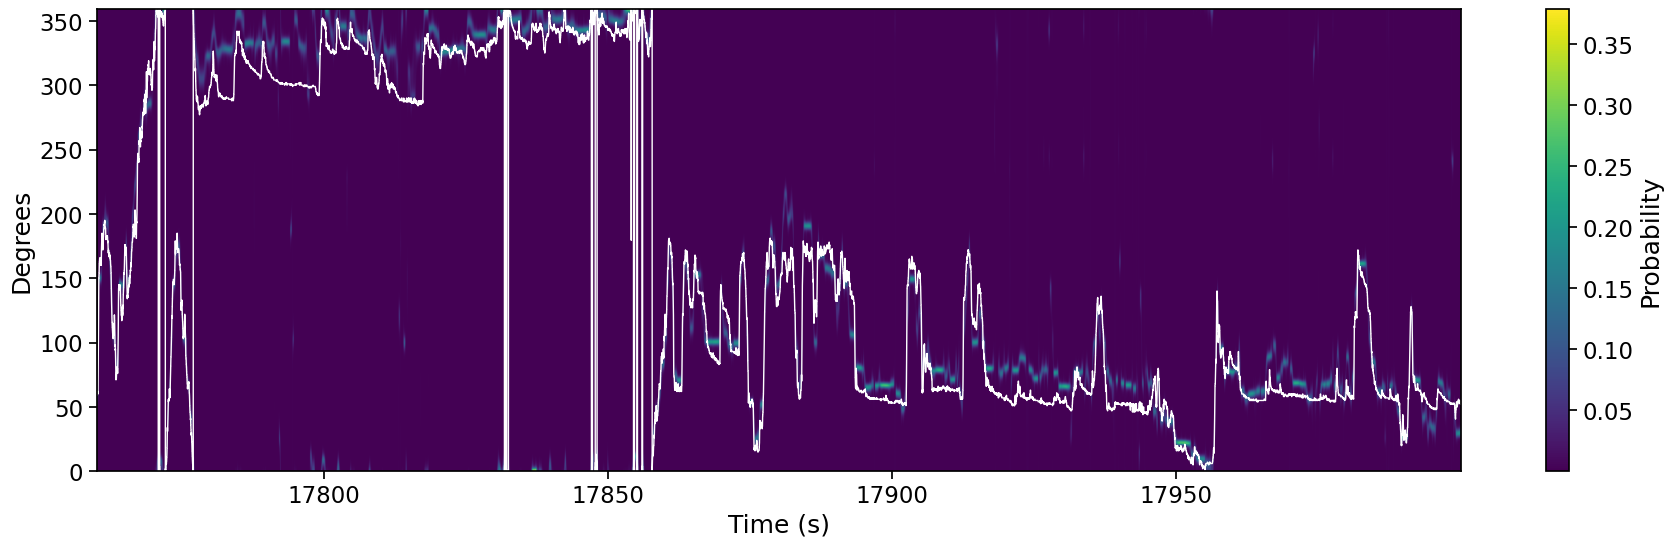

In [42]:
d = angle[~is_training]
times = t[~is_training]

print(f"p_state: {p_state}, movement_var: {movement_var}, place_bin_size: {place_bin_size}")
compare_timeseries(d, pos_max, times=times)
compare_heatmap(d, feature, times=times)

p_state: 0.85, movement_var: 2.0, place_bin_size: 1.0, bin_size: 1
MACE: 1.568
CRME: 1.813


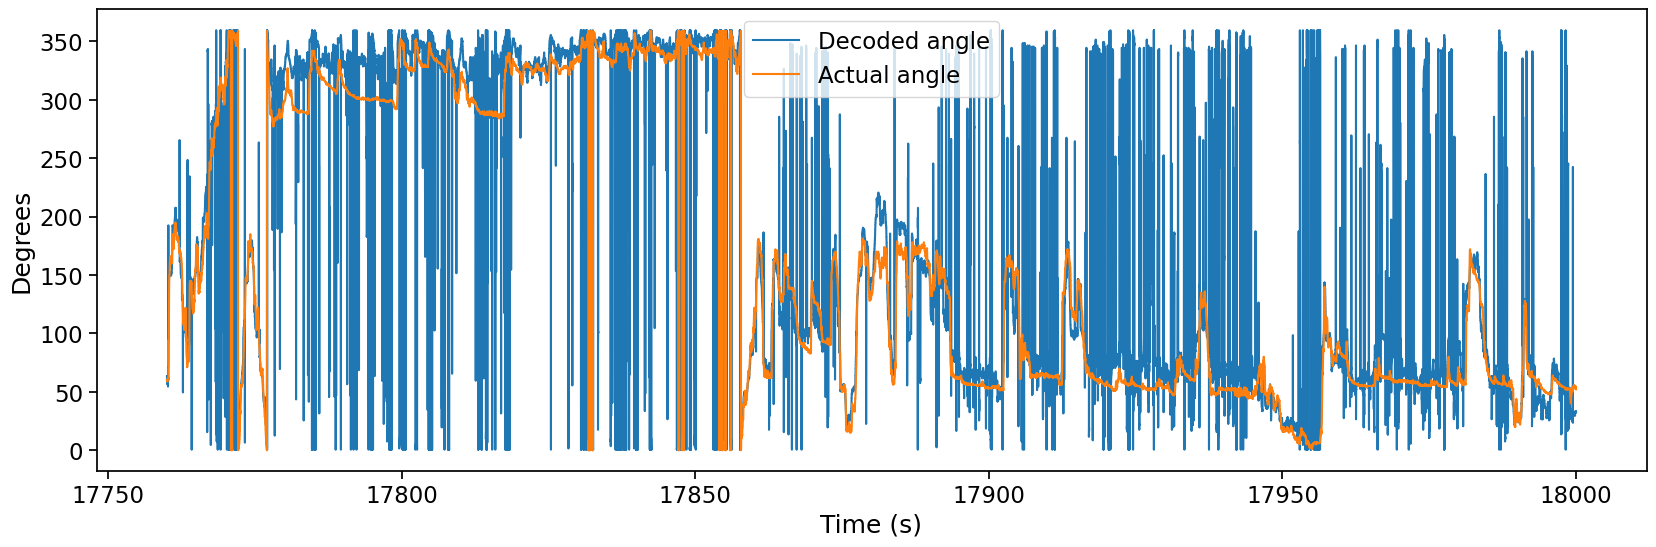

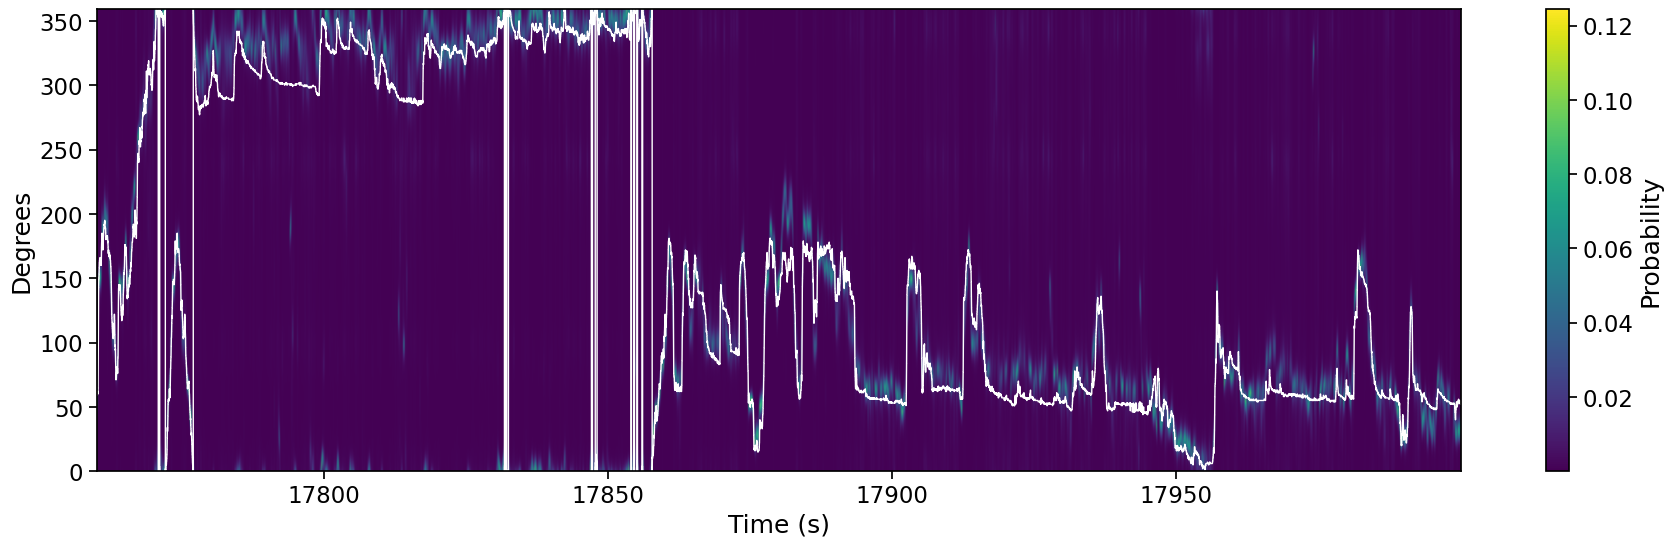

In [72]:
d = angle[~is_training]
times = t[~is_training]

print(f"p_state: {p_state}, movement_var: {movement_var}, place_bin_size: {place_bin_size}, bin_size: {bin_size}")
compare_timeseries(d, pos_max, times=times)
compare_heatmap(d, feature, times=times)

p_state: 0.95, movement_var: 20.0, place_bin_size: 1.0, bin_size: 10
MACE: 1.597
CRME: 1.834


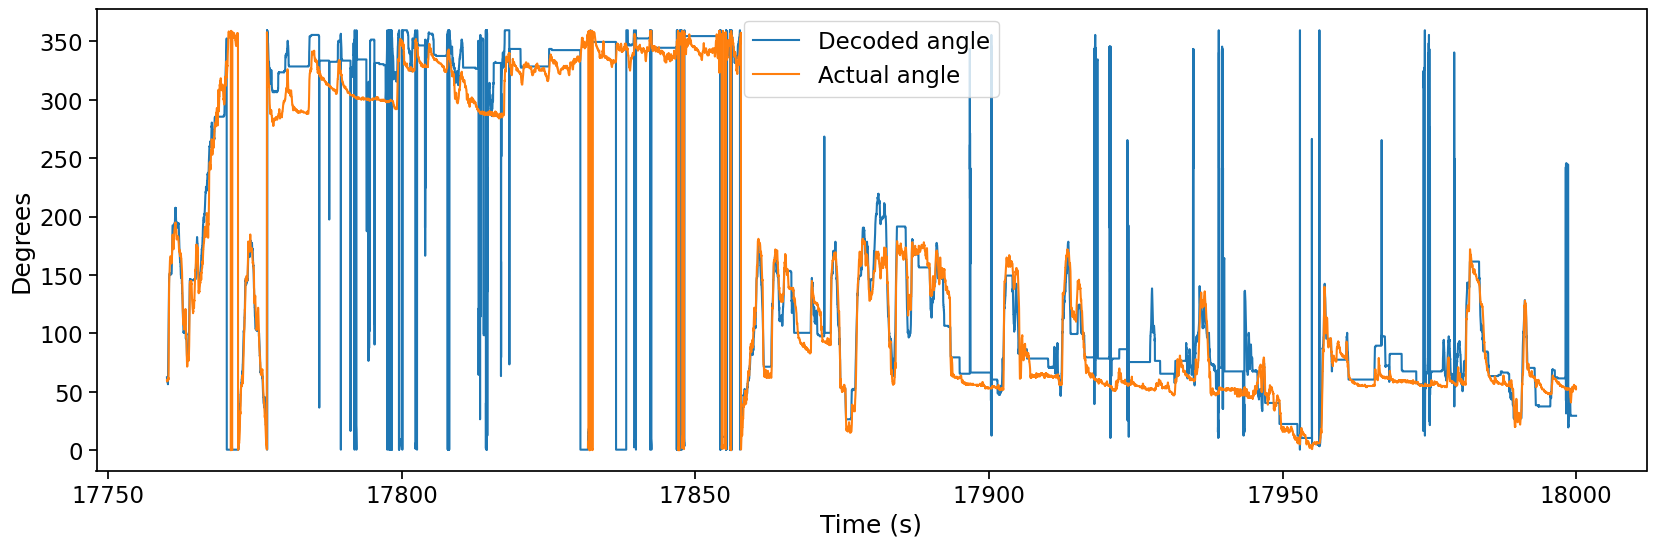

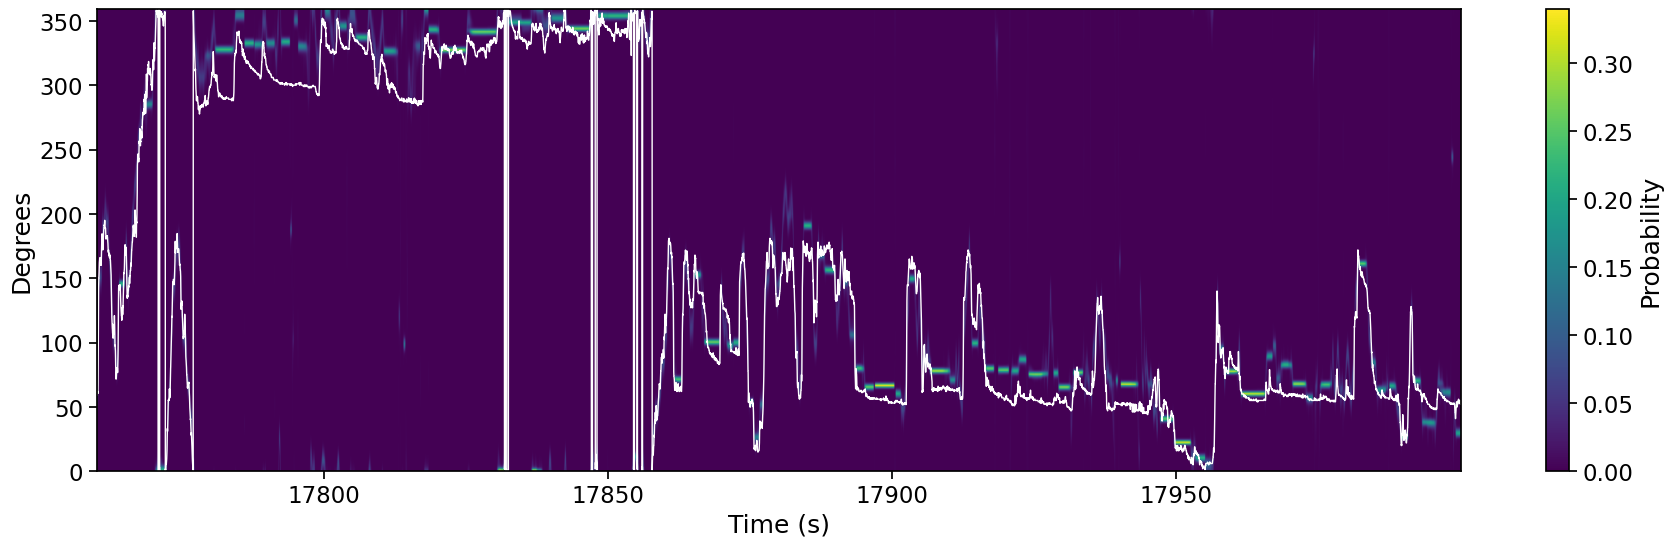

In [60]:
d = angle[~is_training]
times = t[~is_training]

print(f"p_state: {p_state}, movement_var: {movement_var}, place_bin_size: {place_bin_size}, bin_size: {bin_size}")
compare_timeseries(d, pos_max, times=times)
compare_heatmap(d, feature, times=times)

p_state: 0.996, movement_var: 20.0, place_bin_size: 1.0, bin_size: 10
MACE: 1.597
CRME: 1.834


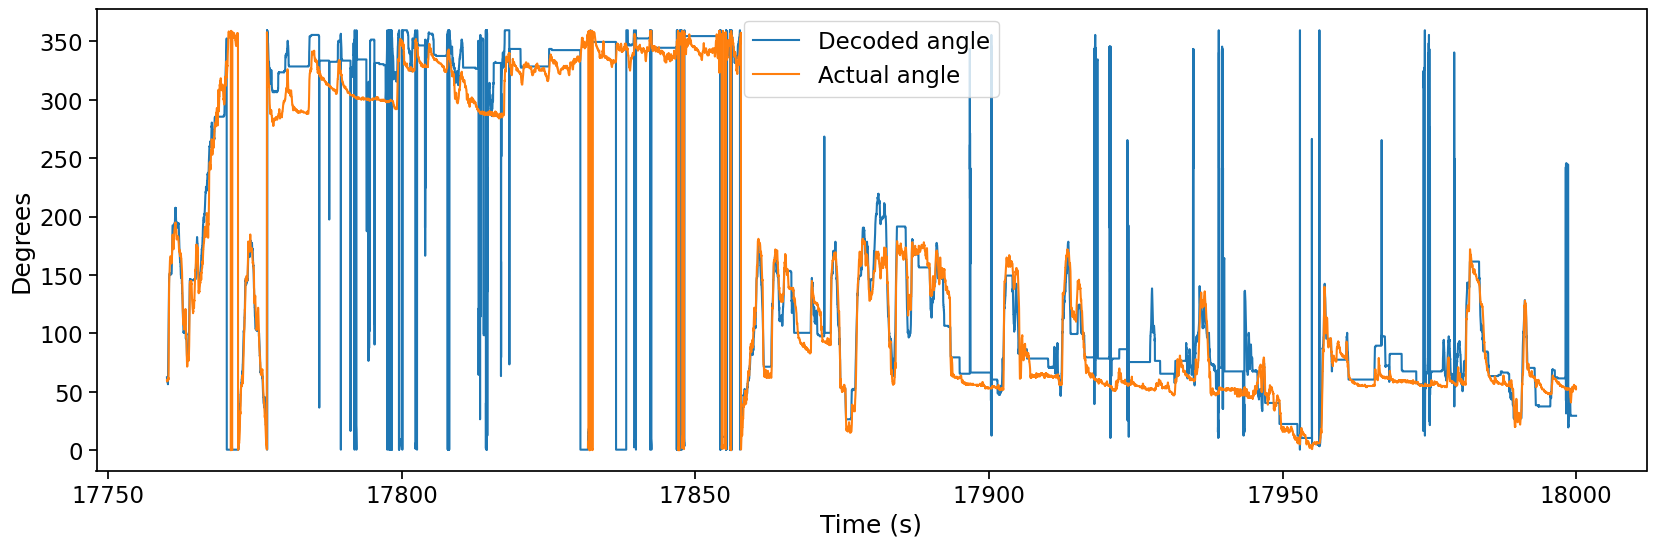

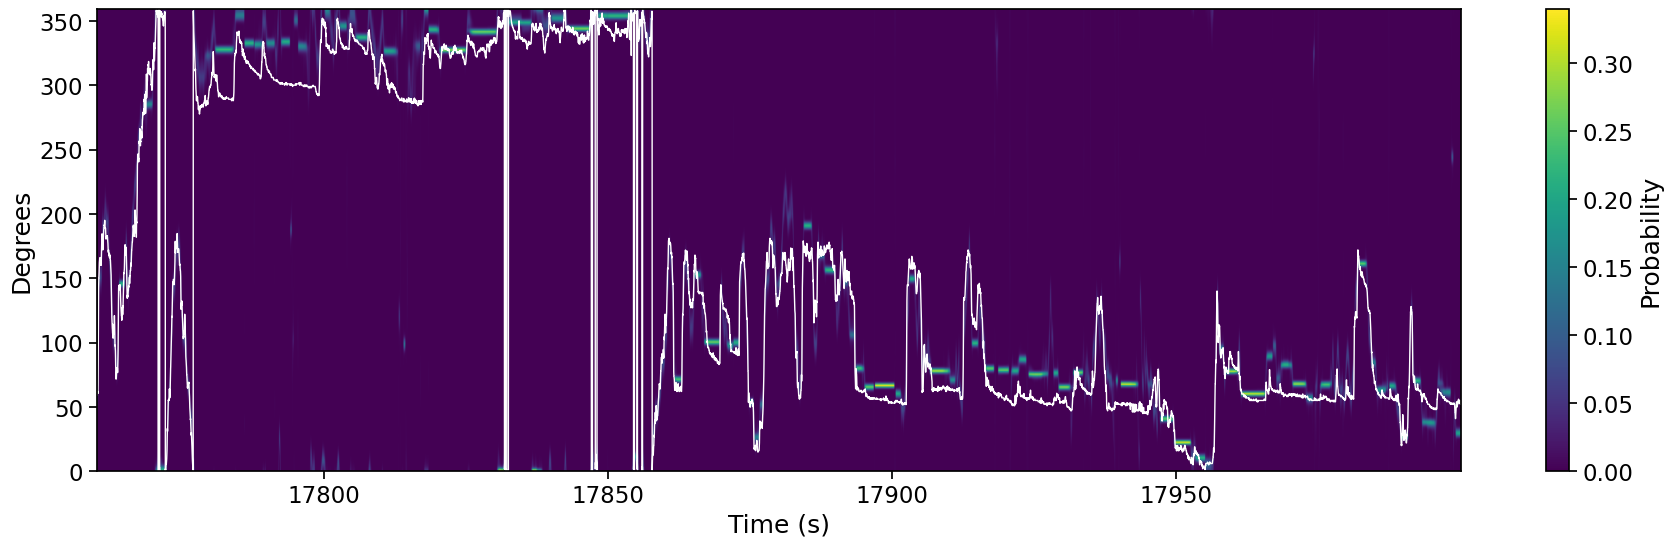

In [55]:
d = angle[~is_training]
times = t[~is_training]

print(f"p_state: {p_state}, movement_var: {movement_var}, place_bin_size: {place_bin_size}, bin_size: {bin_size}")
compare_timeseries(d, pos_max, times=times)
compare_heatmap(d, feature, times=times)

Text(0, 0.5, 'Firing Rate')

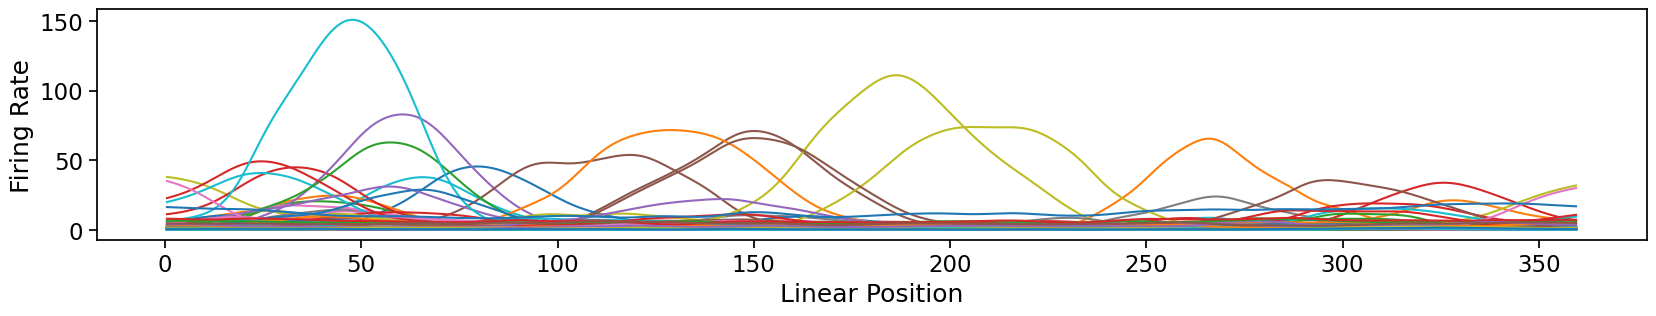

In [35]:
fig, ax = plt.subplots(figsize=(20, 3))
(classifier.place_fields_[('',0)] * 1000).plot(x="position", hue="neuron", add_legend=False, ax=ax)
ax.set_xlabel('Linear Position')
ax.set_ylabel('Firing Rate')

In [38]:
epochs = nap.IntervalSet(start=[34000], end=[36000])
sleep_spikes = hd_spikes.restrict(epochs).count(bin_size=2, time_units='ms').astype(np.bool)

In [39]:
classifier.fit(angle, spikes)
decoded = classifier.predict(sleep_spikes.values, time=sleep_spikes.times(), state_names=['continuous', 'fragmented', 'stationary'])

c:\Users\iii9781\nrem_sc\.venv\Lib\site-packages\replay_trajectory_classification\likelihoods\spiking_likelihood_kde.py:119: RuntimeWarning: divide by zero encountered in log
  return np.exp(np.log(mean_rate) + np.log(marginal_density) - np.log(occupancy))


  0%|          | 0/81 [00:00<?, ?it/s]

In [40]:
prob_state = decoded.acausal_posterior.sum(dim="position").to_numpy() # Shape (N, 3)
pos_max = decoded.acausal_posterior.sum(dim="state").idxmax(dim="position").to_numpy() # Shape (N,)

# Use column_stack to combine them along the second dimension
combined = np.column_stack([prob_state, pos_max])
print(combined.shape)
combined

(1000000, 4)


array([[4.08805846e-01, 4.45217919e-02, 5.46672362e-01, 2.42496922e+02],
       [4.09731915e-01, 4.06689227e-02, 5.49599162e-01, 2.42496922e+02],
       [4.10474247e-01, 3.72456932e-02, 5.52280059e-01, 2.42496922e+02],
       ...,
       [4.31645799e-01, 2.87009459e-02, 5.39653255e-01, 2.40496947e+02],
       [4.30622426e-01, 3.22078155e-02, 5.37169759e-01, 2.40496947e+02],
       [4.29402260e-01, 3.61627952e-02, 5.34434944e-01, 2.40496947e+02]],
      shape=(1000000, 4))

In [41]:
sleep_decoded_tsdf = nap.TsdFrame(t=decoded['time'].to_numpy()-30000,
                                  d=combined,
                                  columns=['continuous', 'fragmented', 'stationary', 'position'])
sleep_decoded_tsdf

Time (s)      continuous    fragmented    stationary    position
----------  ------------  ------------  ------------  ----------
4000.001        0.408806     0.0445218      0.546672     242.497
4000.003        0.409732     0.0406689      0.549599     242.497
4000.005        0.410474     0.0372457      0.55228      242.497
4000.007        0.411053     0.034207       0.55474      242.497
4000.009        0.411486     0.0315123      0.557002     242.497
4000.011        0.41179      0.029125       0.559085     242.497
4000.013        0.411979     0.0270123      0.561009     242.497
...
5999.987        0.434182     0.0182416      0.547577     240.497
5999.989        0.433745     0.0204009      0.545854     240.497
5999.991        0.433188     0.0228395      0.543972     240.497
5999.993        0.432494     0.0255929      0.541913     240.497
5999.995        0.431646     0.0287009      0.539653     240.497
5999.997        0.430622     0.0322078      0.53717      240.497
5999.999        0.429

<Axes: ylabel='Count'>

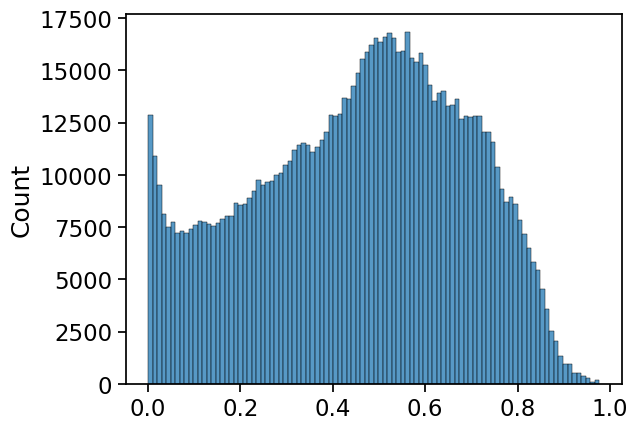

In [45]:
sns.histplot(sleep_decoded_tsdf['stationary'].values, bins=100)

In [43]:
sleep_decoded_tsdf.save(INTERIM_DATA_PATH / unit_id / "sleep_decoded_tdf.npz")

In [46]:
np.save(INTERIM_DATA_PATH / unit_id / "sleep_classified_angle_34000_36000.nc", sleep_decoded.acausal_posterior.to_numpy())